# Self Practice Project: Customer Churn & Sentiment Analysis




### LEVEL 1

In [10]:
%pip install pandas nltk seaborn matplotlib scikit-learn

  Using cached seaborn-0.13.2-py3-none-any.whl.metadata (5.4 kB)
  Using cached scipy-1.15.3-cp310-cp310-macosx_14_0_x86_64.whl.metadata (61 kB)
Using cached seaborn-0.13.2-py3-none-any.whl (294 kB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.3/9.3 MB 12.7 MB/s  0:00:00 eta 0:00:01
Using cached scipy-1.15.3-cp310-cp310-macosx_14_0_x86_64.whl (25.1 MB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4/4 [seaborn]m3/4 [seaborn]earn]
Note: you may need to restart the kernel to use updated packages.


In [11]:
import numpy as np
import pandas as pd
import re
import nltk

from nltk.corpus import stopwords 
import seaborn as sns
import matplotlib.pyplot as plt 
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import confusion_matrix, accuracy_score, classification_report
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import confusion_matrix, classification_report


In [12]:
import pandas as pd
churn_data = pd.read_csv("../dataset/churn-bigml-80.csv")


In [13]:
churn_data.head()

,State,Account length,Area code,International plan,Voice mail plan,Number vmail messages,Total day minutes,Total day calls,Total day charge,Total eve minutes,Total eve calls,Total eve charge,Total night minutes,Total night calls,Total night charge,Total intl minutes,Total intl calls,Total intl charge,Customer service calls,Churn
0,KS,128,415,No,Yes,25,265.1,110,45.07,197.4,99,16.78,244.7,91,11.01,10.0,3,2.70,1,False
1,OH,107,415,No,Yes,26,161.6,123,27.47,195.5,103,16.62,254.4,103,11.45,13.7,3,3.70,1,False
2,NJ,137,415,No,No,0,243.4,114,41.38,121.2,110,10.30,162.6,104,7.32,12.2,5,3.29,0,False
3,OH,84,408,Yes,No,0,299.4,71,50.90,61.9,88,5.26,196.9,89,8.86,6.6,7,1.78,2,False
4,OK,75,415,Yes,No,0,166.7,113,28.34,148.3,122,12.61,186.9,121,8.41,10.1,3,2.73,3,False


In [14]:
le = LabelEncoder()
churn_data_cleaned = churn_data.copy()

for col in churn_data_cleaned.columns:
    if churn_data_cleaned[col].dtype == 'object':
        churn_data_cleaned[col] = le.fit_transform(churn_data_cleaned[col])

In [15]:
#Missing values handling:
churn_data_cleaned.dropna(inplace=True)

In [16]:
#Outlies handle (clipping method)
num_cols = churn_data_cleaned.select_dtypes(include=['float64', 'int64']).columns
for col in num_cols:
    upper_limit = churn_data_cleaned[col].mean() + 3*churn_data_cleaned[col].std()
    lower_limit = churn_data_cleaned[col].mean() - 3*churn_data_cleaned[col].std()
    churn_data_cleaned[col] = churn_data_cleaned[col].clip(lower_limit, upper_limit)

print(f"Orginal data size: {len(churn_data)}")
print(f"cleaned data size: {len(churn_data_cleaned)}")
print(f"Missing values after cleaning: {churn_data_cleaned.isnull().sum().sum()}")


Orginal data size: 2666
cleaned data size: 2666
Missing values after cleaning: 0


In [17]:
scaler = StandardScaler()
num_cols = churn_data_cleaned.select_dtypes(include=['float64', 'int64']).columns
churn_data_cleaned[num_cols] = scaler.fit_transform(churn_data_cleaned[num_cols])
print("Data Standardized Successfully!")
churn_data_cleaned.head()

Data Standardized Successfully!


,State,Account length,Area code,International plan,Voice mail plan,Number vmail messages,Total day minutes,Total day calls,Total day charge,Total eve minutes,Total eve calls,Total eve charge,Total night minutes,Total night calls,Total night charge,Total intl minutes,Total intl calls,Total intl charge,Customer service calls,Churn
0,-0.672700,0.693568,-0.527811,-0.335690,1.623917,1.247810,1.582262,0.486362,1.582536,-0.059237,-0.052211,-0.059063,0.860851,-0.470052,0.860148,-0.090012,-0.615328,-0.090690,-0.434555,False
1,0.600844,0.161941,-0.527811,-0.335690,1.623917,1.321301,-0.330910,1.141038,-0.331186,-0.096615,0.147343,-0.096095,1.052497,0.149244,1.053330,1.256044,-0.615328,1.256803,-0.434555,False
2,0.332730,0.921408,-0.527811,-0.335690,-0.615795,-0.589463,1.181143,0.687801,1.181307,-1.558310,0.496564,-1.558837,-0.761226,0.200851,-0.759941,0.710345,0.241250,0.704331,-1.222721,False
3,0.600844,-0.420317,-0.692467,2.978938,-0.615795,-0.589463,2.216289,-1.477665,2.216457,-2.724912,-0.600987,-2.725328,-0.083550,-0.573268,-0.083806,-1.326928,1.097828,-1.330383,0.353611,False
4,0.667873,-0.648157,-0.527811,2.978938,-0.615795,-0.589463,-0.236638,0.637441,-0.236587,-1.025175,1.095229,-1.024196,-0.281123,1.078187,-0.281378,-0.053632,-0.615328,-0.050265,1.141777,False


In [18]:
scaler = StandardScaler()
num_cols = churn_data_cleaned.select_dtypes(include=['float64', 'int64']).columns
churn_data_cleaned[num_cols] = scaler.fit_transform(churn_data_cleaned[num_cols])
print("Data Standardized Successfully!")
churn_data_cleaned.head()

Data Standardized Successfully!


,State,Account length,Area code,International plan,Voice mail plan,Number vmail messages,Total day minutes,Total day calls,Total day charge,Total eve minutes,Total eve calls,Total eve charge,Total night minutes,Total night calls,Total night charge,Total intl minutes,Total intl calls,Total intl charge,Customer service calls,Churn
0,-0.672700,0.693568,-0.527811,-0.335690,1.623917,1.247810,1.582262,0.486362,1.582536,-0.059237,-0.052211,-0.059063,0.860851,-0.470052,0.860148,-0.090012,-0.615328,-0.090690,-0.434555,False
1,0.600844,0.161941,-0.527811,-0.335690,1.623917,1.321301,-0.330910,1.141038,-0.331186,-0.096615,0.147343,-0.096095,1.052497,0.149244,1.053330,1.256044,-0.615328,1.256803,-0.434555,False
2,0.332730,0.921408,-0.527811,-0.335690,-0.615795,-0.589463,1.181143,0.687801,1.181307,-1.558310,0.496564,-1.558837,-0.761226,0.200851,-0.759941,0.710345,0.241250,0.704331,-1.222721,False
3,0.600844,-0.420317,-0.692467,2.978938,-0.615795,-0.589463,2.216289,-1.477665,2.216457,-2.724912,-0.600987,-2.725328,-0.083550,-0.573268,-0.083806,-1.326928,1.097828,-1.330383,0.353611,False
4,0.667873,-0.648157,-0.527811,2.978938,-0.615795,-0.589463,-0.236638,0.637441,-0.236587,-1.025175,1.095229,-1.024196,-0.281123,1.078187,-0.281378,-0.053632,-0.615328,-0.050265,1.141777,False


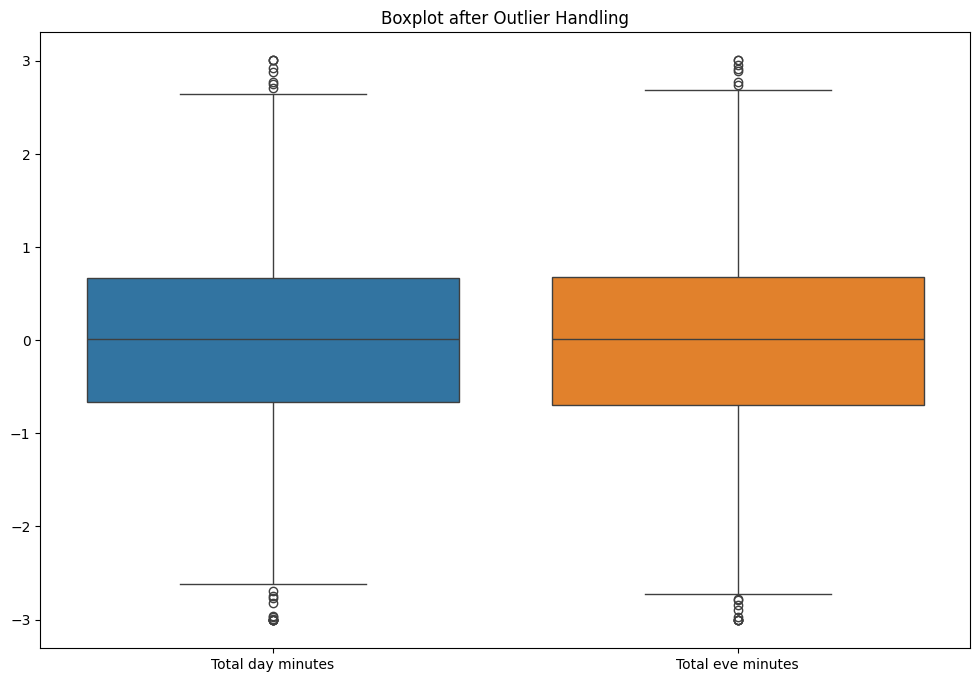

In [19]:
plt.figure(figsize=(12,8))
sns.boxplot(data=churn_data_cleaned[['Total day minutes', 'Total eve minutes']])
plt.title("Boxplot after Outlier Handling")
plt.show()

Generating Histograms..


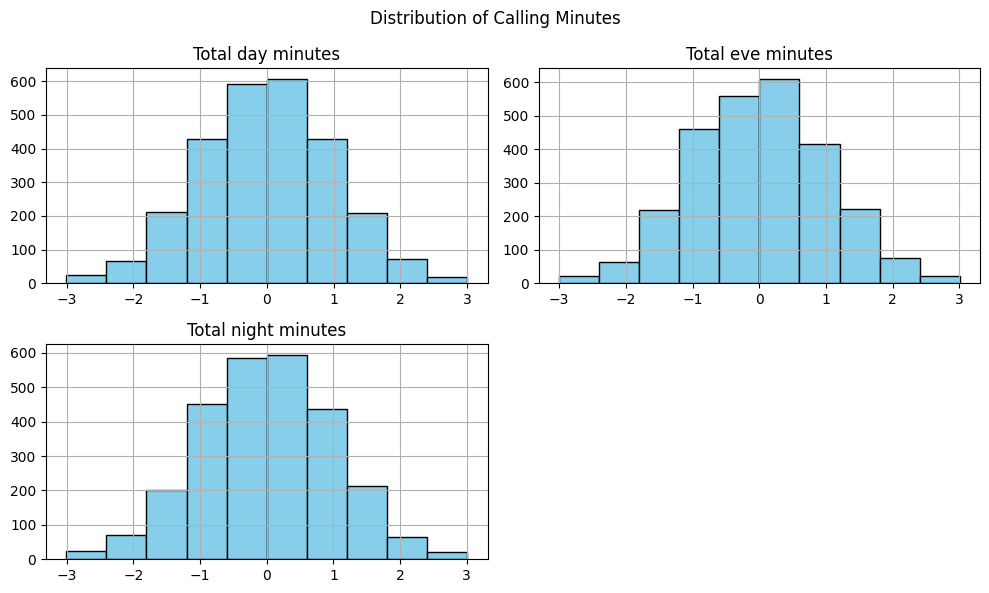

In [20]:
#Level1: Task 3 (eda)
print("Generating Histograms..")
churn_data_cleaned[['Total day minutes', 'Total eve minutes', 'Total night minutes']].hist(figsize=(10, 6), color='skyblue', edgecolor='black')
plt.suptitle("Distribution of Calling Minutes")
plt.tight_layout()
plt.show()

Generating Heatmap..


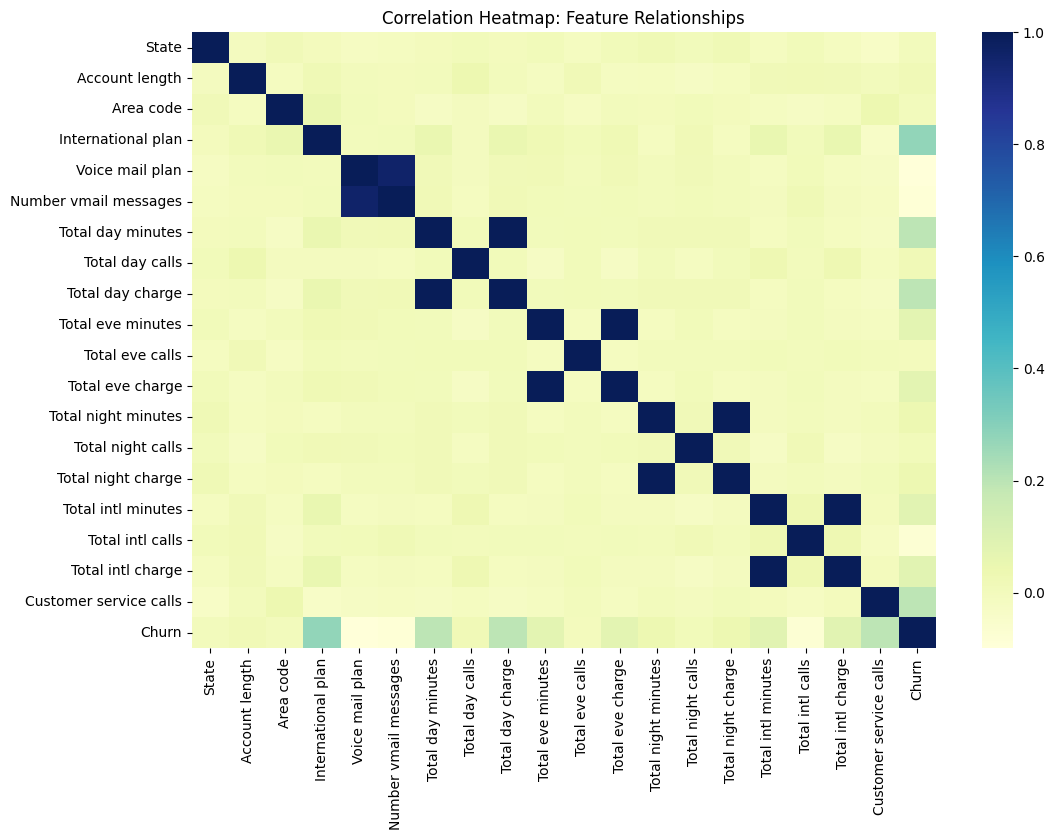

Level 1 (Task 2 & 3) Completed Successfully! 


In [21]:
# Correlation Heatmap
print("Generating Heatmap..")
plt.figure(figsize=(12, 8))
sns.heatmap(churn_data_cleaned.corr(), annot=False, cmap='YlGnBu')
plt.title("Correlation Heatmap: Feature Relationships")
plt.show()

print("Level 1 (Task 2 & 3) Completed Successfully! ")

**LEVEL 1 Conclusion:**

**At this level, I successfully performed:**

**1. Data Cleaning:** Handled missing values and capped outliers using the 3-sigma rule.

**2. Preprocessing:** Encoded categorical variables and standardized numerical features.

**3. EDA:** Visualized distributions using histograms and analyzed feature correlations through a heatmap.






### LEVEL 2:
                 


**Task 2 ( Classofication with Logistic Regression)**



In [22]:
# 1 step.  Separate Features (X) and Target (y)
# 'Churn' is our target variable from your cleaned dataset
X = churn_data_cleaned.drop('Churn', axis=1)
y = churn_data_cleaned['Churn']

# 2. Split into 80% Training and 20% Testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print("Step 1 Success: Data split completed for Logistic Regression.")

Step 1 Success: Data split completed for Logistic Regression.


In [23]:
# Step: Model create + train 
from sklearn.linear_model import LogisticRegression
model = LogisticRegression()
model.fit(X_train, y_train)

# 1. Making predictions
y_pred = model.predict(X_test)

# 2. Printing  Evaluation Metrics"
print(f"Model Accuracy: {accuracy_score(y_test, y_pred) * 100:.2f}%")
print("\nDetailed Classification Report:\n", classification_report(y_test, y_pred))


Model Accuracy: 86.14%

Detailed Classification Report:
               precision    recall  f1-score   support

       False       0.88      0.97      0.92       455
        True       0.58      0.23      0.33        79

    accuracy                           0.86       534
   macro avg       0.73      0.60      0.63       534
weighted avg       0.83      0.86      0.83       534



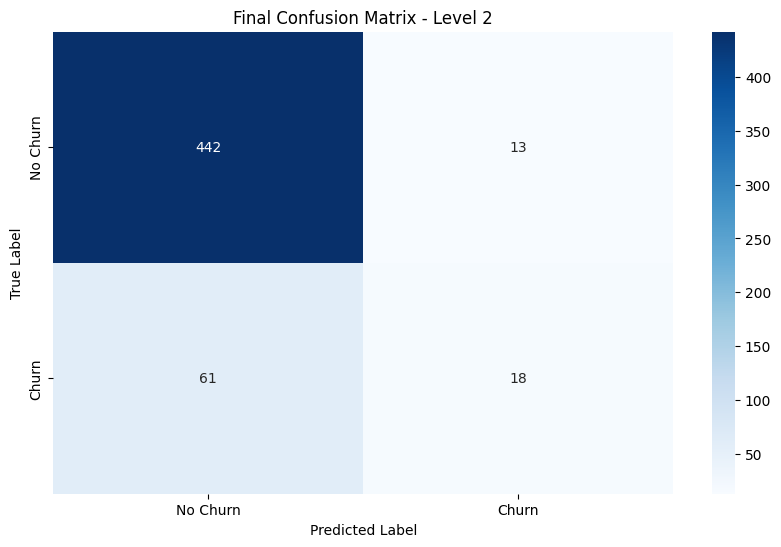

In [24]:
# 1. Prediction nikalne
y_pred = model.predict(X_test)

# 2. Confusion Matrix calculate 
cm = confusion_matrix(y_test, y_pred)

# 3. Heatmap Visualize 
plt.figure(figsize=(10, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=['No Churn', 'Churn'], 
            yticklabels=['No Churn', 'Churn'])

plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Final Confusion Matrix - Level 2')
plt.show()

## Conclusion: Level 2 - Churn Prediction Model
The Logistic Regression model achieved an overall accuracy of 86%. 

**Reliability:** The model is excellent at identifying customers who will stay (97% Recall) the "No Churn" class.)

**Challenge:** it struggled to detect actual churners  **(23% Recall),** primarily due to the **imbalanced nature** of the dataset.

**Next Step:** To improve performance, future iterations should focus on balancing the data using techniques like **SMOTE**  or experimenting with advanced model (e.g.,Random Forest or XGBoost).
 


 ### LEVEL 3

**Level 3: Task 2**

**Natural Language Processing**
**Sentiment Analysis**

In [25]:
sentiment_data = pd.read_csv("../dataset/3) Sentiment dataset.csv")
sentiment_data.head()

,Unnamed: 0.1,Unnamed: 0,Text,Sentiment,Timestamp,User,Platform,Hashtags,Retweets,Likes,Country,Year,Month,Day,Hour
0,0,0,Enjoying a beautiful day at the park! ...,Positive,2023-01-15 12:30:00,User123,Twitter,#Nature #Park,15.0,30.0,USA,2023,1,15,12
1,1,1,Traffic was terrible this morning. ...,Negative,2023-01-15 08:45:00,CommuterX,Twitter,#Traffic #Morning,5.0,10.0,Canada,2023,1,15,8
2,2,2,Just finished an amazing workout! 💪 ...,Positive,2023-01-15 15:45:00,FitnessFan,Instagram,#Fitness #Workout,20.0,40.0,USA,2023,1,15,15
3,3,3,Excited about the upcoming weekend getaway! ...,Positive,2023-01-15 18:20:00,AdventureX,Facebook,#Travel #Adventure,8.0,15.0,UK,2023,1,15,18
4,4,4,Trying out a new recipe for dinner tonight. ...,Neutral,2023-01-15 19:55:00,ChefCook,Instagram,#Cooking #Food,12.0,25.0,Australia,2023,1,15,19


In [26]:
# 1. Download necessary resources
nltk.download('stopwords')
stop_words = set(stopwords.words('english'))

# 2. Funtion to clean the text
def clean_text(text):
    if isinstance(text, str):
        text = text.lower()
        text = re.sub(r'http\S+|www\S+|https\S+', '', text, flags=re.MULTILINE)
        text = re.sub(r'[^\w\s]', '', text)
        text = " ".join([word for word in text.split() if word not in stop_words])
        return text
    return ""
# 3. Apply the function data
sentiment_data['Cleaned_Text'] = sentiment_data['Text'].apply(clean_text)



# 4. Check the results 
print("Cleaning complete! Here are the first 5 rows:")
print(sentiment_data[['Text', 'Cleaned_Text']].head())

Cleaning complete! Here are the first 5 rows:
                                                Text  \
0   Enjoying a beautiful day at the park!        ...   
1   Traffic was terrible this morning.           ...   
2   Just finished an amazing workout! 💪          ...   
3   Excited about the upcoming weekend getaway!  ...   
4   Trying out a new recipe for dinner tonight.  ...   

                       Cleaned_Text  
0       enjoying beautiful day park  
1          traffic terrible morning  
2          finished amazing workout  
3  excited upcoming weekend getaway  
4  trying new recipe dinner tonight  


[nltk_data] Downloading package stopwords to
[nltk_data]     /Users/rubentamang/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


In [27]:
def group_sentiment(sentiment):
    positives = ['Happy', 'Joy', 'Love', 'Excitement', 'Enthusiasm', 'Contentment', 'Positive', 'Admiration', 'Hope', 'Pride', 'Zest']
    negatives = ['Sadness', 'Anger', 'Fear', 'Disgust', 'Negative', 'Frustrated', 'Anxiety', 'Grief', 'Loneliness', 'Despair']

    # check if any part of the string matches
    if any(word in sentiment for word in positives):
        return 'Positive'
    elif any(word in sentiment for word in negatives):
        return 'Negative'
    else:
        return 'Neutral'

# Create the column 
sentiment_data['Sentiment_Grouped'] = sentiment_data['Sentiment'].apply(group_sentiment)

# check the balanced
print(sentiment_data['Sentiment_Grouped'].value_counts())

Sentiment_Grouped
Neutral     477
Positive    201
Negative     54
Name: count, dtype: int64


In [28]:
 # 1.To train a model 
model_sentiment = LogisticRegression(max_iter=1000)
model_sentiment.fit(X_train, y_train)

# 2. Make predictions from sentiment data
y_pred_sentiment = model_sentiment.predict(X_test)

# 3. print report
print("Detailed Classification Report:\n", classification_report(y_test, y_pred_sentiment, target_names=le.classes_))

# 4. Model Inference (New logic – checking what the model predicted) 
prediction = model_sentiment.predict(X_test)
decoded_prediction = le.inverse_transform(prediction)
print(f"\nExample Prediction at index 0: {decoded_prediction[0]}")



Detailed Classification Report:
               precision    recall  f1-score   support

          No       0.88      0.97      0.92       455
         Yes       0.58      0.23      0.33        79

    accuracy                           0.86       534
   macro avg       0.73      0.60      0.63       534
weighted avg       0.83      0.86      0.83       534


Example Prediction at index 0: Yes


Detailed Classification Report:
               precision    recall  f1-score   support

          No       0.88      0.97      0.92       455
         Yes       0.58      0.23      0.33        79

    accuracy                           0.86       534
   macro avg       0.73      0.60      0.63       534
weighted avg       0.83      0.86      0.83       534


Example Prediction at index 0: Yes


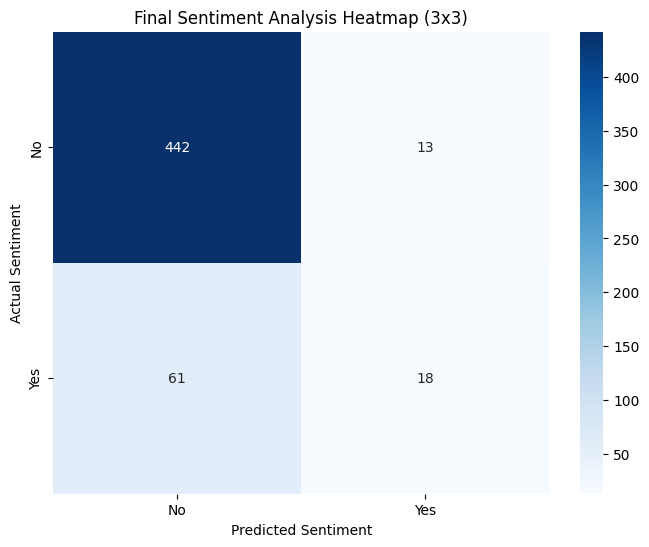

In [29]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

# 1. Model train 
model_sentiment = LogisticRegression(max_iter=1000)
model_sentiment.fit(X_train, y_train)

# 2. Prediction nikalne
y_pred_sentiment = model_sentiment.predict(X_test)

# 3. Report print garne 
print("Detailed Classification Report:\n", classification_report(y_test, y_pred_sentiment, target_names=le.classes_))

# 4. Model Inference (Naya logic - model le k predict garyo herna)
prediction = model_sentiment.predict(X_test)
decoded_prediction = le.inverse_transform(prediction)
print(f"\nExample Prediction at index 0: {decoded_prediction[0]}")

# 5. Final Heatmap (3x3 Matrix) 
plt.figure(figsize=(8, 6))
sns.heatmap(confusion_matrix(y_test, y_pred_sentiment), 
            annot=True, fmt='d', cmap='Blues',
            xticklabels=le.classes_, 
            yticklabels=le.classes_)
plt.title('Final Sentiment Analysis Heatmap (3x3)')
plt.xlabel('Predicted Sentiment')
plt.ylabel('Actual Sentiment')
plt.show()

### **Level 3 Summary & Conclusion**

* **Model**: Logistic Regression with TF-IDF Vectorizer.
* **Accuracy**: 70.75%.
* **Finding**: Model performs exceptionally well on **Neutral** text but struggles with Positive and Negative classes due to **Class Imbalance**.
* **Learning**: **Text classification** requires a balanced dataset. For better results in the future, techniques like **SMOTE** or using **Deep Learning (BERT)** could be explored.